# CoXAM From the Published Corpus

Runs CoXAM's forward simulation using only what ships in `assets/` — **no AI
model is trained and no explanations are generated**.

`decision_tree_logistic_regression_experiment_workflow.ipynb` is the other half
of the pair: it trains an MLP, fits DT/LR surrogates from that model, then
simulates. This notebook skips both and reads the study's published tables:

| | trained here | source |
|---|---|---|
| AI predictions | no | `assets/ai_dataset/coxam/none.csv` |
| DT / LR explanations | no | `assets/explanations/CoXAM/` |
| feature values | no | `assets/ai_dataset/coxam/values.csv` |
| CoXAM policies | no | `coxam/trained_policies/` checkpoints |

Same `xaikitTest` object and the same `run_experiment` call as the other
notebook — only `source="assets"` and the absence of `train_AI_model` differ.

## 1. Setup

In [14]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "tutorials" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import src as xk

from src.virtual_experiment_executor.experiment_simualtion.CoXAM.coxam_trial_executor import (
    COXAM_CORPUS_FEATURES,
    COXAM_CORPUS_FEATURE_ALIASES,
    coxam_available_instance_ids,
)

OUTPUT_DIR = REPO_ROOT / "tutorials" / "coxam_load_default_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

APP_ID = "wine_quality"   # the corpus also ships mushrooms
print("corpus features:", list(COXAM_CORPUS_FEATURES[APP_ID]))
print("loader aliases :", COXAM_CORPUS_FEATURE_ALIASES[APP_ID])

corpus features: ['Alcohol', 'Sulphates', 'SO2', 'Vinegar Taint', 'pH', 'Chlorides']
loader aliases : {'chlorides': 'Chlorides'}


## 2. Create the Workflow and Design

In [15]:
xaikitTest = xk.xaikitTest(output_dir=OUTPUT_DIR)

XAI_TYPES = ["decision_tree", "logistic_regression"]
TESTED_W_XAI = [True, False]

xaikitTest.add_iv("xai_type", "within", XAI_TYPES, randomization="block")
xaikitTest.add_iv("tested_w_xai", "within", TESTED_W_XAI, randomization="trial")

xaikitTest.add_cv("user_task", ["forward_simulation"])
xaikitTest.add_dv("forward_accuracy", ["continuous"])

xaikitTest.validate_design(show=True)


IV configuration:
  xai_type             type=within   randomization=block levels=['decision_tree', 'logistic_regression']
  tested_w_xai         type=within   randomization=trial levels=[True, False]

CVs: ['user_task']
DVs: ['forward_accuracy']


({'xai_type': {'type': 'within',
   'levels': ['decision_tree', 'logistic_regression'],
   'randomization': 'block'},
  'tested_w_xai': {'type': 'within',
   'levels': [True, False],
   'randomization': 'trial'}},
 {'user_task': ['forward_simulation']},
 {'forward_accuracy': ['continuous']})

## 3. Prepare the Dataset on the Corpus's Feature Set

Two details make `source="assets"` usable, and both matter:

- **Names.** The loader spells two features differently from the corpus
  (`chlorides` → `Chlorides`, `Gill Spacing` → `Gill`). Those confirmed
  equivalences live in `COXAM_CORPUS_FEATURE_ALIASES`; anything not listed is
  treated as a genuinely different feature.
- **Order.** `rank_features_by_target=False` is required. The default reorders
  features by target correlation, and the corpus's `a0..a5` are *positional* —
  a permutation would attach every coefficient and tree threshold to the wrong
  feature, so the runner refuses rather than guessing.

In [16]:
COXAM_WINE_FEATURES = ["Alcohol", "Sulphates", "SO2", "Vinegar Taint", "pH", "chlorides"]

data = xaikitTest.prepare_dataset(
    dataset_id=APP_ID,
    model_type="mlp",
    feature_cols=COXAM_WINE_FEATURES,
    rank_features_by_target=False,   # keep the corpus's positional order
    show_available=False,
    show_summary=True,
)

print("feature order:", list(data.raw_feature_names))

Dataset   : wine_quality  (1599 rows, 6 model features)
Features  : ['Alcohol', 'Sulphates', 'SO2', 'Vinegar Taint', 'pH', 'chlorides']
Encoding  : one-hot
Train set : 1279 samples  (80%)
Test set  : 320 samples  (20%)
Class balance (train) -> class 0: 1105
Class balance (train) -> class 1: 174
First test instanceIds: [434, 213, 1447, 231, 763, 1472, 472, 1327, 766, 19]
feature order: ['Alcohol', 'Sulphates', 'SO2', 'Vinegar Taint', 'pH', 'chlorides']


## 4. Generate Trials Over Instances the Corpus Serves

`allowed_instance_ids` keeps every trial to an instance the published tables can
explain — without it a trial could name an instance the corpus never covered.

In [17]:
instance_ids = coxam_available_instance_ids(APP_ID)
print(f"instances in the corpus: {len(instance_ids)}")

trial_result = xaikitTest.generate_trials(
    model_name="mlp",
    participants_per_between_condition=4,
    allowed_instance_ids=instance_ids,
    counterbalancing_strategy="balanced_latin_square",
    trial_randomization_strategy="balanced",
    output_dir="trials",
    preview_rows=6,
    show=True,
)

print("no AI model trained:", xaikitTest.trained_ai_model is None)

instances in the corpus: 400
Counterbalancing strategy: balanced_latin_square_bradley_1958
Participant assignments: 4 total
Instance pool rows: 76
Trial rows: 48
Exported trial artifacts:
  CSV     : /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/coxam_load_default_output/trials/trials.csv
  JSON    : /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/coxam_load_default_output/trials/trials.json
  Summary : /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/coxam_load_default_output/trials/design_summary.json

Previewing first 6 trial rows:
{'participantId': 1, 'trialId': 1, 'phase': 'testing', 'phaseTrialId': 1, 'block': 1, 'trialWithinBlock': 1, 'withinCondition': 'decision_tree', 'xai_type': 'decision_tree', 'tested_w_xai': False, 'dataId': 'wine_quality', 'instanceId': '217'}
{'participantId': 1, 'trialId': 2, 'phase': 'testing', 'phaseTrialId': 2, 'block': 1, 'trialWithinBlock': 2, 'withinCondition': 'decision_tree', 'xai_type': 'de

## 5. Simulate With CoXAM

`source="assets"` reads the published surrogates instead of fitting new ones,
which is what lets this run with no trained model. Passing `source="fit"` here
would raise, because fitting needs one.

In [18]:
xaikitTest.set_cognitive_model(cognitive_model_id="coxam")

simulated = xaikitTest.run_experiment(mode="whole_experiment", source="fit")

print("simulated rows:", len(simulated))
preview_columns = [
    column
    for column in (
        "participantId", "instanceId", "xai_type", "tested_w_xai",
        "selected_strategy", "ai_prediction", "agent_prediction", "forward_accuracy",
    )
    if column in simulated.columns
]
simulated[preview_columns].head(8)

RuntimeError: No trained AI model available. Call study.train_AI_model(...) first.

In [ ]:
from IPython.display import Image, display

# Code cell option

# Local image file
display(Image(filename="path/to/your_image.png"))

# URL image (optional)
# display(Image(url="https://example.com/your_image.png"))

## 6. Results

In [ ]:
print(simulated["selected_strategy"].value_counts().to_string())

simulated.groupby(["xai_type", "tested_w_xai"])["forward_accuracy"].agg(
    ["mean", "size"]
).round(3)

selected_strategy
dt_traversal      24
lr_heuristic      15
lr_calculation     9


mean  size
xai_type            tested_w_xai             
decision_tree       False         0.833    12
                    True          0.917    12
logistic_regression False         0.500    12
                    True          0.417    12

ResultGrid(figure=<Figure size 680x280 with 2 Axes>, axes=array([[<Axes: title={'center': 'Forward Accuracy by XAI Type'}, xlabel='XAI Type', ylabel='Forward Accuracy'>,
        <Axes: title={'center': 'Forward Accuracy by Tested W XAI'}, xlabel='Tested W XAI', ylabel='Forward Accuracy'>]],
      dtype=object), summary=             iv                dv  index                level  count  \
0      xai_type  forward_accuracy      0        decision_tree      4   
1      xai_type  forward_accuracy      1  logistic_regression      4   
2  tested_w_xai  forward_accuracy      0                False      4   
3  tested_w_xai  forward_accuracy      1                 True      4   

       mean       std       sem      ci95  
0  0.875000  0.083333  0.041667  0.132602  
1  0.458333  0.083333  0.041667  0.132602  
2  0.666667  0.192450  0.096225  0.306231  
3  0.666667  0.136083  0.068041  0.216538  )

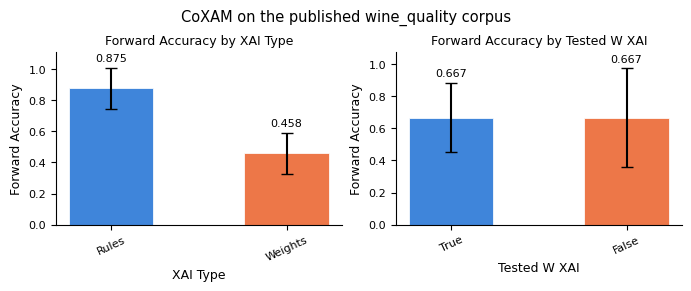

In [ ]:
xaikitTest.plot_results_grid(
    ivs=["xai_type", "tested_w_xai"],
    dvs=["forward_accuracy"],
    phase=None,
    title=f"CoXAM on the published {APP_ID} corpus",
)

## 7. Human vs CoXAM on the Real Study Data

Sections 1-6 simulate a *new* design. This is the study's own fitted results —
the humans beside the model fitted to them — in one call.

**These are two different CoXAM models.** Above, the RL meta-policy picks a
strategy per trial. The published fit is a DDM-with-timing model (`T_enc`,
`ddm_a`, `ddm_s`, `retrieval_threshold`, `lapse`) estimated per participant by
GP optimisation on response NLL and time MAE jointly. The fitted table is what
the paper reports.

In [ ]:
from src.result_visualizer import human_vs_model_report, study_comparison

report_path = human_vs_model_report("coxam", OUTPUT_DIR / "human_vs_coxam.html")
print("wrote", report_path)

wrote /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/coxam_load_default_output/human_vs_coxam.html


`human_vs_model_report()` with no arguments covers every study that has
fitted results on disk. `study_comparison` returns the panels instead of
rendering them, so the numbers can be inspected directly.

In [ ]:
coxam = study_comparison("coxam")
print(coxam.name, "|", coxam.task)
print("participants:", coxam.participants, "| panels:", len(coxam.panels))

for panel in coxam.panels[:2]:
    print()
    print(panel.title)
    print(panel.to_frame().to_string(index=False))

CoXAM | Forward simulation (137, mushrooms) and counterfactual editing (270, both datasets)
participants: 270 | panels: 7

Forward simulation — mushrooms, w/o XAI
series category     mean    error interval  n
 Human    Rules 0.694955 0.041781   95% CI 51
 Human  Weights 0.622330 0.041730   95% CI 43
 Human   Hybrid 0.598810 0.048557   95% CI 43
 CoXAM    Rules 0.654746 0.037714   95% CI 51
 CoXAM  Weights 0.630183 0.044112   95% CI 43
 CoXAM   Hybrid 0.577177 0.044810   95% CI 43

Forward simulation — mushrooms, w/ XAI
series category     mean    error interval  n
 Human    Rules 0.784548 0.039794   95% CI 51
 Human  Weights 0.659241 0.039800   95% CI 43
 Human   Hybrid 0.684486 0.038741   95% CI 43
 CoXAM    Rules 0.771739 0.035058   95% CI 51
 CoXAM  Weights 0.650571 0.043424   95% CI 43
 CoXAM   Hybrid 0.655744 0.036685   95% CI 43


## Show Human vs Cognitive Model Fitting

## 8. What This Notebook Shows

- CoXAM runs end to end with **no AI training and no explanation generation** —
  every input is a table or checkpoint already in the repository.
- `coxam_available_instance_ids` is what keeps trials to instances the corpus
  can serve.
- The meta-policy switches strategy per trial: `dt_traversal` under a decision
  tree, `lr_calculation` / `lr_heuristic` under logistic regression.
- `source="assets"` needs the study's features to match the corpus in **both**
  spelling and order — `COXAM_CORPUS_FEATURE_ALIASES` handles the first,
  `rank_features_by_target=False` the second.
- `human_vs_model_report()` renders every study that has fitted results in one
  call; `study_comparison(name)` returns the panels to inspect instead. CoAX is
  replayed through `run_coax_human_replay`, so both its series carry real
  confidence intervals.
- The fitted CoXAM is a different model from the meta-policy simulated above —
  the DDM the paper reports, not the RL agent.

To train your own model and fit surrogates against it instead, use
`decision_tree_logistic_regression_experiment_workflow.ipynb`, which calls the
same `run_experiment` with `source="fit"`.